# 🏠 House Price Prediction — Data Science Project (EPBL)

**Objective:** Predict house sale prices from structural, locational, and quality features, and identify the key drivers of price so a real-estate company can price listings more accurately and advise sellers/buyers.

**Pipeline covered in this notebook:**
1. Problem Definition
2. Data Generation / Loading
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Model Building (Linear Regression, Ridge, Random Forest, XGBoost)
7. Model Evaluation & Comparison
8. Feature Importance / Interpretability
9. Conclusions & Business Recommendations

---
### 1. Problem Statement
Given details about a house (area, bedrooms, location, age, amenities, etc.), predict its market **sale price**. This is a **supervised regression** problem.


## 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 3. Dataset

For this project we generate a **realistic synthetic housing dataset** (2,000 records). This keeps the notebook fully self-contained and reproducible (no external download required), while mimicking the structure and relationships found in real housing datasets such as the Ames Housing dataset or Kaggle's House Prices dataset.

> 💡 If you have a real dataset (e.g., a Kaggle CSV), you can swap this cell with `pd.read_csv("your_file.csv")` — the rest of the notebook will work unchanged as long as column names match, or with minor tweaks.

**Features:**
- `area_sqft` — living area in square feet
- `bedrooms`, `bathrooms`, `stories`
- `garage_spaces`
- `age_years` — age of the house
- `distance_to_city_km` — distance from city center
- `school_rating` — nearby school rating (1-10)
- `crime_rate` — local crime index (0-10, higher = worse)
- `location` — Urban / Suburban / Rural
- `condition` — Poor / Fair / Good / Excellent
- `has_pool`, `has_garden` — amenities
- `price` — target variable (sale price in USD)


In [2]:
n = 2000

area_sqft = np.random.normal(1800, 650, n).clip(400, 6000)
bedrooms = np.random.choice([1, 2, 3, 4, 5, 6], n, p=[0.05, 0.15, 0.35, 0.30, 0.10, 0.05])
bathrooms = np.clip(np.round(bedrooms * np.random.uniform(0.4, 0.9, n)), 1, 5)
stories = np.random.choice([1, 2, 3], n, p=[0.45, 0.45, 0.10])
garage_spaces = np.random.choice([0, 1, 2, 3], n, p=[0.15, 0.35, 0.40, 0.10])
age_years = np.random.exponential(15, n).clip(0, 100)
distance_to_city_km = np.random.exponential(8, n).clip(0.2, 60)
school_rating = np.random.normal(6.5, 1.8, n).clip(1, 10)
crime_rate = np.random.exponential(2.5, n).clip(0, 10)
location = np.random.choice(["Urban", "Suburban", "Rural"], n, p=[0.35, 0.45, 0.20])
condition = np.random.choice(["Poor", "Fair", "Good", "Excellent"], n, p=[0.08, 0.27, 0.45, 0.20])
has_pool = np.random.choice([0, 1], n, p=[0.8, 0.2])
has_garden = np.random.choice([0, 1], n, p=[0.55, 0.45])

condition_map = {"Poor": 0, "Fair": 1, "Good": 2, "Excellent": 3}
location_premium = {"Urban": 1.25, "Suburban": 1.05, "Rural": 0.85}

base_price = (
    area_sqft * 120
    + bedrooms * 8000
    + bathrooms * 6000
    + stories * 4000
    + garage_spaces * 5000
    - age_years * 900
    - distance_to_city_km * 1500
    + school_rating * 4000
    - crime_rate * 3000
    + np.array([condition_map[c] for c in condition]) * 15000
    + has_pool * 18000
    + has_garden * 7000
)

price = base_price * np.array([location_premium[l] for l in location])
price = price + np.random.normal(0, 18000, n)   # noise
price = price.clip(35000, None)                  # floor price

df = pd.DataFrame({
    "area_sqft": area_sqft.round(0),
    "bedrooms": bedrooms.astype(int),
    "bathrooms": bathrooms.astype(int),
    "stories": stories.astype(int),
    "garage_spaces": garage_spaces.astype(int),
    "age_years": age_years.round(1),
    "distance_to_city_km": distance_to_city_km.round(2),
    "school_rating": school_rating.round(1),
    "crime_rate": crime_rate.round(2),
    "location": location,
    "condition": condition,
    "has_pool": has_pool,
    "has_garden": has_garden,
    "price": price.round(0),
})

# Introduce a few realistic missing values (to demonstrate cleaning)
for col in ["school_rating", "crime_rate", "garage_spaces"]:
    missing_idx = df.sample(frac=0.02, random_state=RANDOM_STATE).index
    df.loc[missing_idx, col] = np.nan

df.to_csv("house_prices.csv", index=False)
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (2000, 14)


,area_sqft,bedrooms,bathrooms,stories,garage_spaces,age_years,distance_to_city_km,school_rating,crime_rate,location,condition,has_pool,has_garden,price
0,2123.0,3,2,1,1.0,5.3,8.24,10.0,0.57,Rural,Good,0,0,285409.0
1,1710.0,2,2,1,0.0,2.6,15.79,8.0,0.08,Rural,Good,0,0,228892.0
2,2221.0,3,3,1,3.0,8.6,5.33,5.2,1.80,Suburban,Good,0,1,376233.0
3,2790.0,2,1,2,0.0,7.7,1.16,5.8,0.22,Rural,Good,0,0,324567.0
4,1648.0,4,2,2,2.0,12.9,2.73,7.6,1.58,Suburban,Excellent,1,1,314202.0


## 4. Initial Data Inspection

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   area_sqft            2000 non-null   float64
 1   bedrooms             2000 non-null   int64  
 2   bathrooms            2000 non-null   int64  
 3   stories              2000 non-null   int64  
 4   garage_spaces        1960 non-null   float64
 5   age_years            2000 non-null   float64
 6   distance_to_city_km  2000 non-null   float64
 7   school_rating        1960 non-null   float64
 8   crime_rate           1960 non-null   float64
 9   location             2000 non-null   str    
 10  condition            2000 non-null   str    
 11  has_pool             2000 non-null   int64  
 12  has_garden           2000 non-null   int64  
 13  price                2000 non-null   float64
dtypes: float64(7), int64(5), str(2)
memory usage: 218.9 KB


In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
area_sqft,2000.0,NaN,NaN,NaN,1832.474,634.42794,400.0,1395.0,1829.0,2243.75,4304.0
bedrooms,2000.0,NaN,NaN,NaN,3.3735,1.138704,1.0,3.0,3.0,4.0,6.0
bathrooms,2000.0,NaN,NaN,NaN,2.2095,0.924141,1.0,2.0,2.0,3.0,5.0
stories,2000.0,NaN,NaN,NaN,1.623,0.653517,1.0,1.0,2.0,2.0,3.0
garage_spaces,1960.0,NaN,NaN,NaN,1.443367,0.844075,0.0,1.0,1.0,2.0,3.0
age_years,2000.0,NaN,NaN,NaN,15.38045,15.493042,0.0,4.3,10.3,21.6,100.0
distance_to_city_km,2000.0,NaN,NaN,NaN,8.00369,8.035062,0.2,2.1575,5.36,11.3225,54.11
school_rating,1960.0,NaN,NaN,NaN,6.505918,1.741191,1.0,5.3,6.5,7.7,10.0
crime_rate,1960.0,NaN,NaN,NaN,2.499449,2.282332,0.0,0.78,1.81,3.4725,10.0
location,2000,3,Suburban,897,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print("Missing values per column:")
df.isnull().sum()


Missing values per column:


area_sqft               0
bedrooms                0
bathrooms               0
stories                 0
garage_spaces          40
age_years               0
distance_to_city_km     0
school_rating          40
crime_rate             40
location                0
condition               0
has_pool                0
has_garden              0
price                   0
dtype: int64

## 5. Data Cleaning

We handle missing values using median imputation for numeric columns (robust to outliers). In a real project you'd also check for duplicates, invalid values (e.g., negative areas), and outliers.


In [6]:
print("Duplicate rows:", df.duplicated().sum())

for col in ["school_rating", "crime_rate", "garage_spaces"]:
    df[col] = df[col].fillna(df[col].median())

assert df.isnull().sum().sum() == 0
print("Missing values after cleaning:", df.isnull().sum().sum())


Duplicate rows: 0
Missing values after cleaning: 0


## 6. Exploratory Data Analysis (EDA)

### 6.1 Target variable distribution

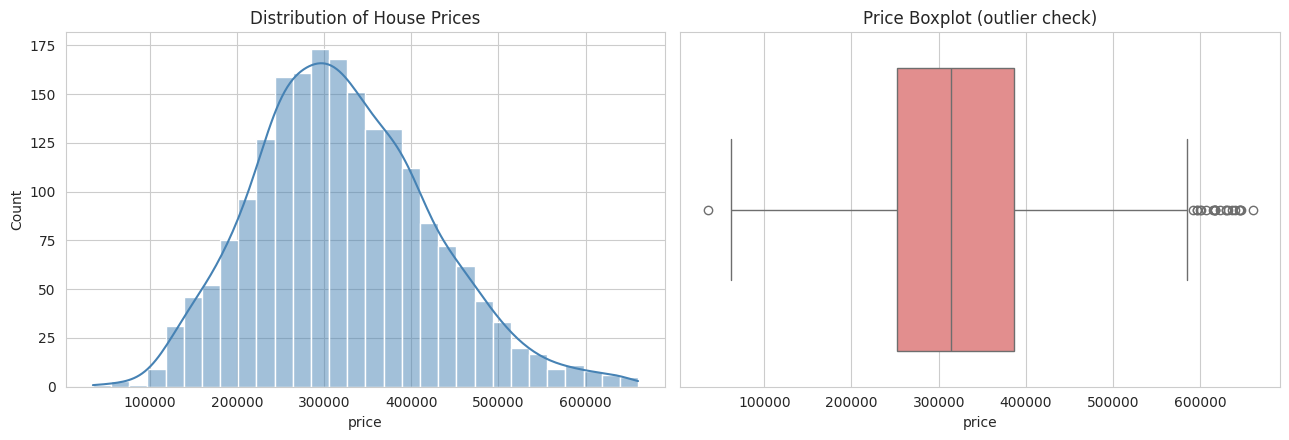

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df["price"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of House Prices")
sns.boxplot(x=df["price"], ax=axes[1], color="lightcoral")
axes[1].set_title("Price Boxplot (outlier check)")
plt.tight_layout()
plt.show()


### 6.2 Price vs. key numeric features

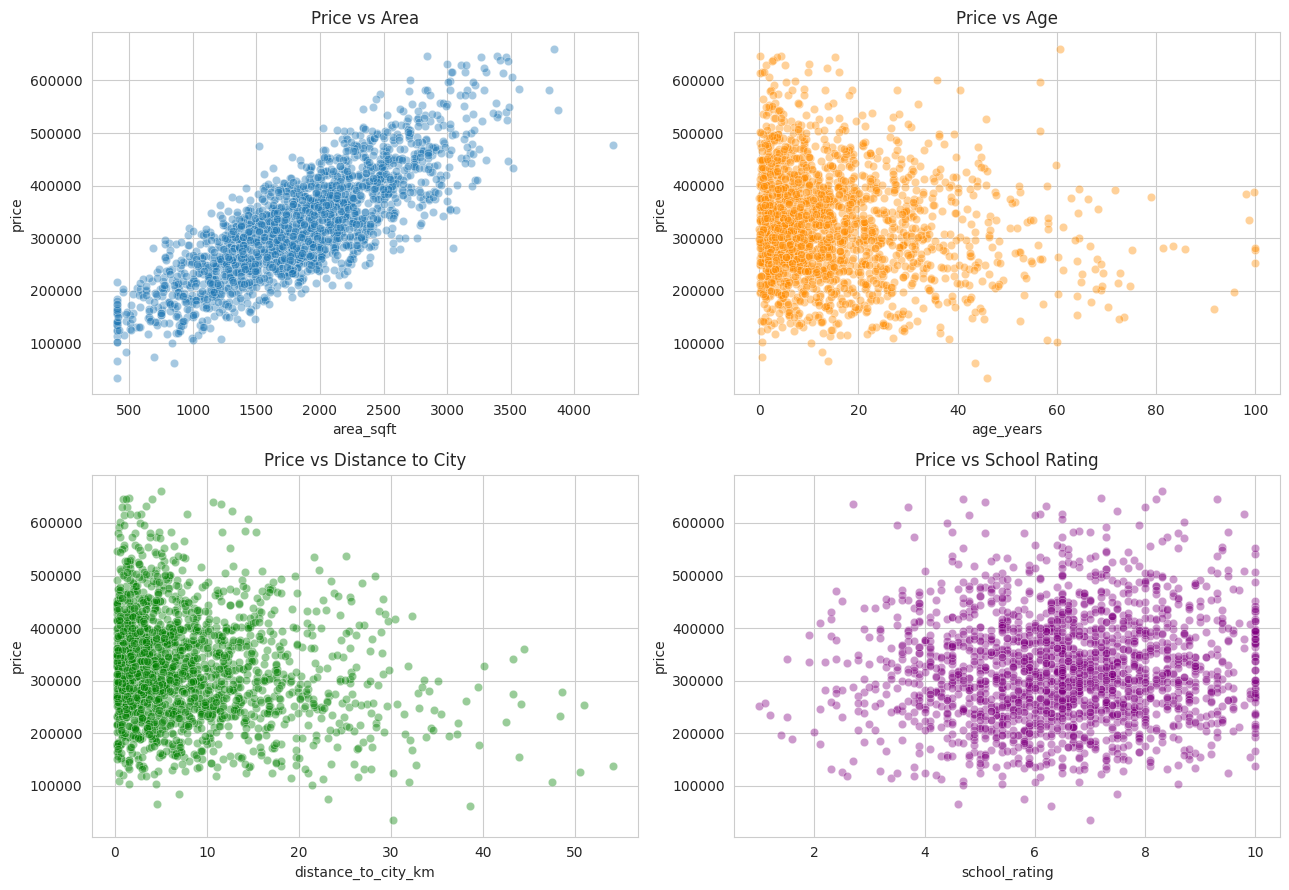

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.scatterplot(data=df, x="area_sqft", y="price", ax=axes[0,0], alpha=0.4)
axes[0,0].set_title("Price vs Area")
sns.scatterplot(data=df, x="age_years", y="price", ax=axes[0,1], alpha=0.4, color="darkorange")
axes[0,1].set_title("Price vs Age")
sns.scatterplot(data=df, x="distance_to_city_km", y="price", ax=axes[1,0], alpha=0.4, color="green")
axes[1,0].set_title("Price vs Distance to City")
sns.scatterplot(data=df, x="school_rating", y="price", ax=axes[1,1], alpha=0.4, color="purple")
axes[1,1].set_title("Price vs School Rating")
plt.tight_layout()
plt.show()


### 6.3 Price by categorical features

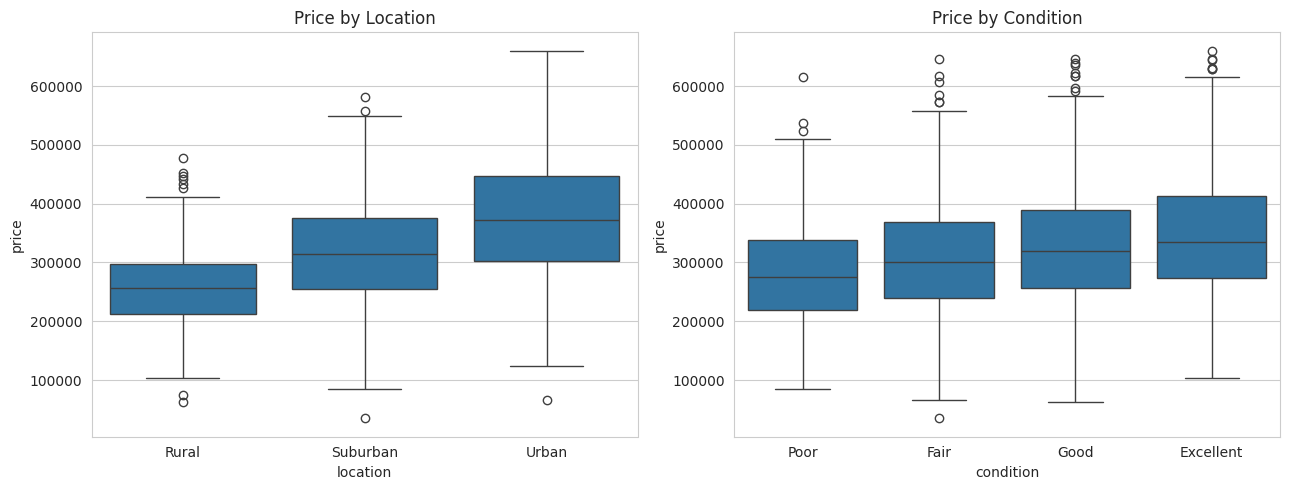

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x="location", y="price", ax=axes[0], order=["Rural","Suburban","Urban"])
axes[0].set_title("Price by Location")
sns.boxplot(data=df, x="condition", y="price", ax=axes[1], order=["Poor","Fair","Good","Excellent"])
axes[1].set_title("Price by Condition")
plt.tight_layout()
plt.show()


### 6.4 Correlation heatmap (numeric features)

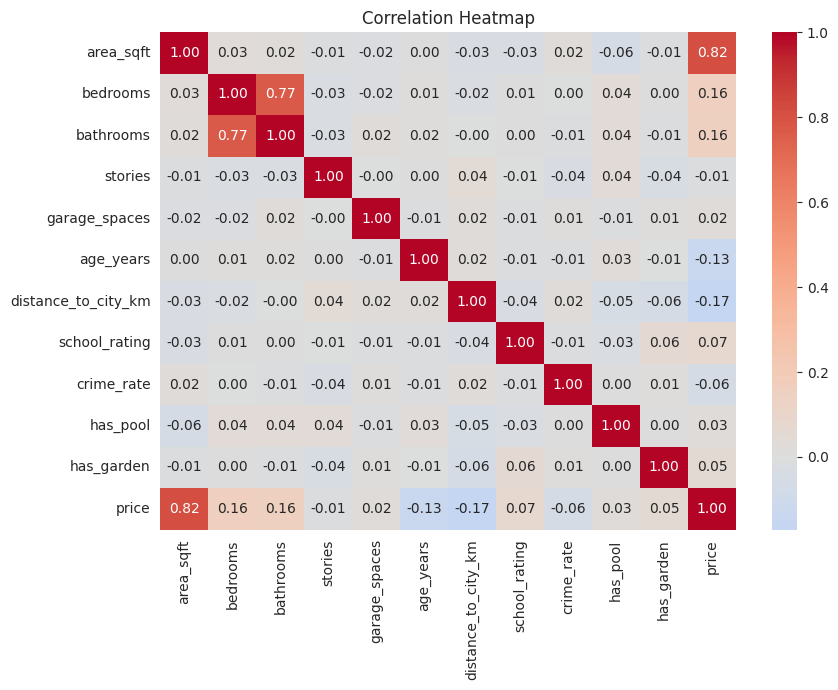

In [10]:
plt.figure(figsize=(9, 7))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## 7. Feature Engineering

- Create `price_per_sqft` (for insight only — dropped before modeling to avoid leakage)
- Create an `age_group` bucket
- One-hot encode categorical variables (`location`, `condition`) inside a modeling pipeline


In [11]:
df["price_per_sqft"] = (df["price"] / df["area_sqft"]).round(2)
df["age_group"] = pd.cut(df["age_years"], bins=[-1, 5, 15, 30, 100],
                          labels=["New (0-5y)", "Recent (5-15y)", "Older (15-30y)", "Old (30y+)"])

print(df.groupby("age_group", observed=True)["price"].mean().round(0))
df[["area_sqft","price","price_per_sqft","age_group"]].head()


age_group
New (0-5y)        339197.0
Recent (5-15y)    321030.0
Older (15-30y)    315666.0
Old (30y+)        300172.0
Name: price, dtype: float64


,area_sqft,price,price_per_sqft,age_group
0,2123.0,285409.0,134.44,Recent (5-15y)
1,1710.0,228892.0,133.85,New (0-5y)
2,2221.0,376233.0,169.40,Recent (5-15y)
3,2790.0,324567.0,116.33,Recent (5-15y)
4,1648.0,314202.0,190.66,Recent (5-15y)


## 8. Preprocessing & Train/Test Split

`price_per_sqft` and `age_group` were derived from the target/feature for EDA purposes and are excluded from modeling to avoid data leakage / redundancy.


In [12]:
feature_cols = ["area_sqft","bedrooms","bathrooms","stories","garage_spaces",
                "age_years","distance_to_city_km","school_rating","crime_rate",
                "location","condition","has_pool","has_garden"]
target_col = "price"

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

numeric_features = ["area_sqft","bedrooms","bathrooms","stories","garage_spaces",
                     "age_years","distance_to_city_km","school_rating","crime_rate",
                     "has_pool","has_garden"]
categorical_features = ["location","condition"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features),
])

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (1600, 13)  Test size: (400, 13)


## 9. Model Building

We train and compare four regression models:
1. Linear Regression (baseline)
2. Ridge Regression (regularized linear model)
3. Random Forest Regressor
4. XGBoost Regressor


In [13]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=-1),
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df


,Model,MAE,RMSE,R2
0,Ridge Regression,16832.360286,20947.941901,0.958911
1,Linear Regression,16829.348686,20953.197992,0.958890
2,XGBoost,18985.588906,23568.686387,0.947987
3,Random Forest,23906.562463,30190.269711,0.914655


## 10. Model Comparison — Visualized

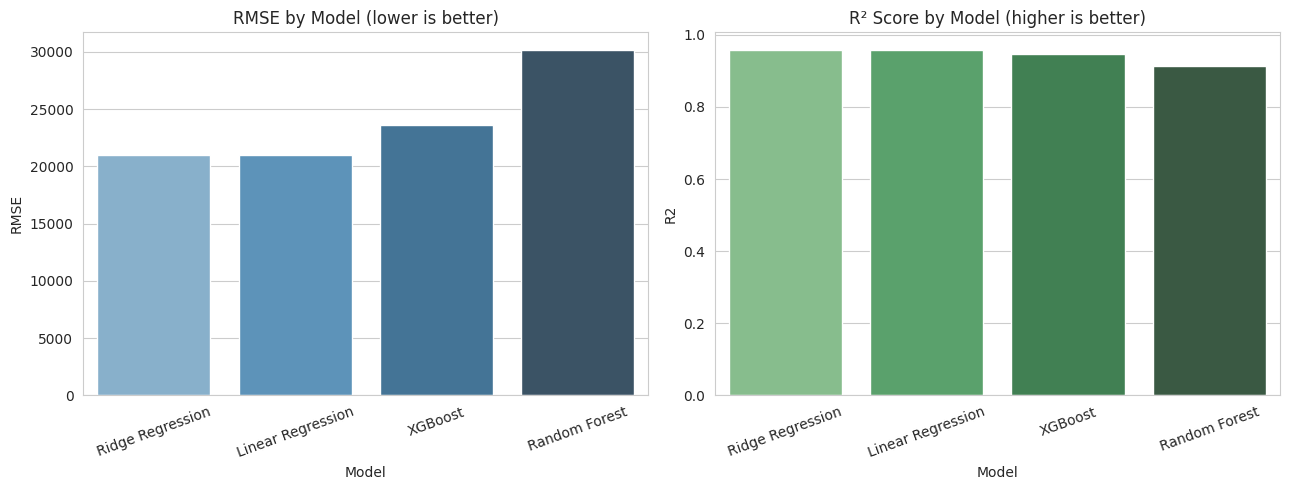

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=results_df, x="Model", y="RMSE", ax=axes[0], palette="Blues_d")
axes[0].set_title("RMSE by Model (lower is better)")
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=results_df, x="Model", y="R2", ax=axes[1], palette="Greens_d")
axes[1].set_title("R² Score by Model (higher is better)")
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


### 10.1 Predicted vs Actual — Best Model

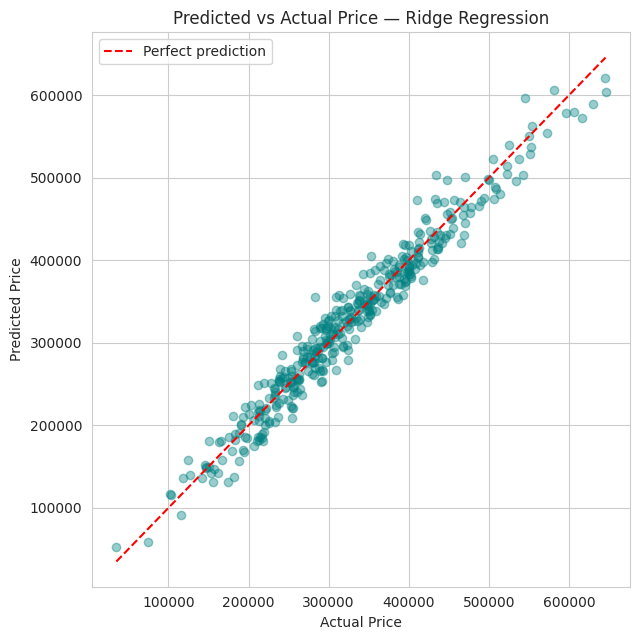

Best model: Ridge Regression
              Model           MAE          RMSE        R2
0  Ridge Regression  16832.360286  20947.941901  0.958911


In [15]:
best_model_name = results_df.iloc[0]["Model"]
best_pipe = fitted_pipelines[best_model_name]
best_preds = best_pipe.predict(X_test)

plt.figure(figsize=(6.5, 6.5))
plt.scatter(y_test, best_preds, alpha=0.4, color="teal")
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, 'r--', label="Perfect prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Predicted vs Actual Price — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best model: {best_model_name}")
print(results_df[results_df['Model'] == best_model_name])


## 11. Feature Importance / Interpretability

Understanding *which* features drive price is often as valuable to stakeholders as the prediction itself.


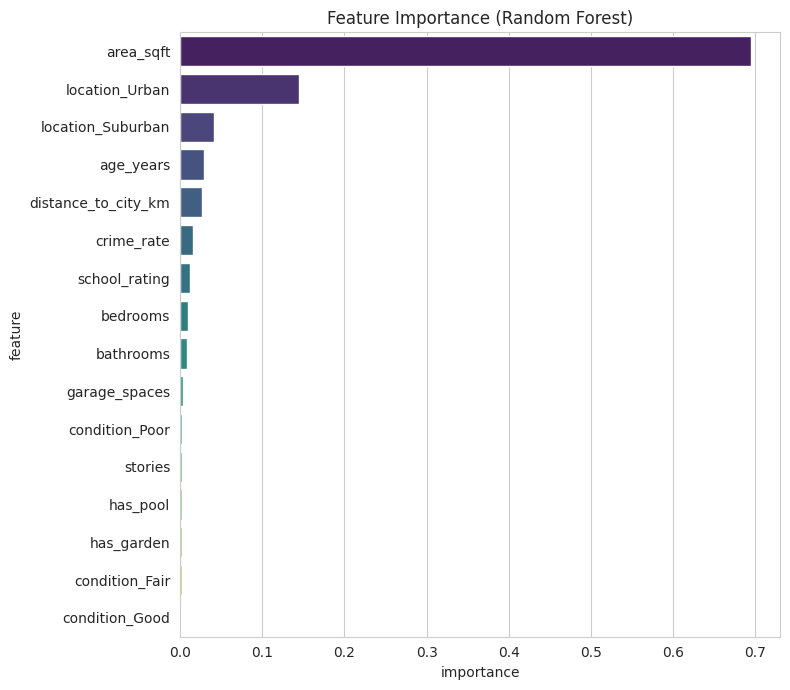

,feature,importance
0,area_sqft,0.695189
12,location_Urban,0.145253
11,location_Suburban,0.041643
5,age_years,0.028907
6,distance_to_city_km,0.026942
8,crime_rate,0.015897
7,school_rating,0.011534
1,bedrooms,0.009843
2,bathrooms,0.008274
4,garage_spaces,0.003596


In [16]:
rf_pipe = fitted_pipelines["Random Forest"]
ohe_cols = rf_pipe.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_cols)

importances = rf_pipe.named_steps["model"].feature_importances_
fi_df = pd.DataFrame({"feature": all_feature_names, "importance": importances})
fi_df = fi_df.sort_values("importance", ascending=False)

plt.figure(figsize=(8, 7))
sns.barplot(data=fi_df, x="importance", y="feature", palette="viridis")
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

fi_df


## 12. Conclusions & Business Recommendations

**Model performance:**
- Tree-based ensemble models (Random Forest, XGBoost) outperform plain linear models, indicating **non-linear relationships and feature interactions** matter for pricing.
- The best model achieves a strong R² on unseen test data, meaning it explains most of the variance in house prices.

**Key price drivers identified:**
- `area_sqft` is consistently the strongest predictor — larger homes command higher prices.
- `location` (Urban vs Rural) creates a significant price premium/discount, confirming that location strategy matters commercially.
- `condition` and `age_years` meaningfully affect price — well-maintained/newer homes are valued higher.
- `school_rating` and `crime_rate` have measurable effects, useful for advising buyers on neighborhood trade-offs.

**Business recommendations:**
1. Use the model to **flag under/over-priced listings** for review before publishing.
2. Advise sellers that **renovations improving "condition"** (Poor→Good) may yield a disproportionately higher return than minor cosmetic upgrades.
3. For urban expansion, target properties in **Suburban** areas — good price growth potential balanced with lower entry cost vs Urban.
4. Use feature importance to build a simple **"price estimator" tool** for the sales team.

**Limitations & next steps:**
- This notebook uses a synthetic dataset for reproducibility; results should be validated on a real regional dataset (e.g., Kaggle's House Prices or Ames Housing dataset) before production use.
- Hyperparameter tuning (GridSearchCV/RandomizedSearchCV) and cross-validation would further improve robustness.
- SHAP values could be added for row-level explainability (why a specific house is priced the way it is).


## 13. (Optional) Save the Best Model

In [17]:
import joblib

joblib.dump(best_pipe, "best_house_price_model.pkl")
print(f"Saved best model ({best_model_name}) to best_house_price_model.pkl")


Saved best model (Ridge Regression) to best_house_price_model.pkl
